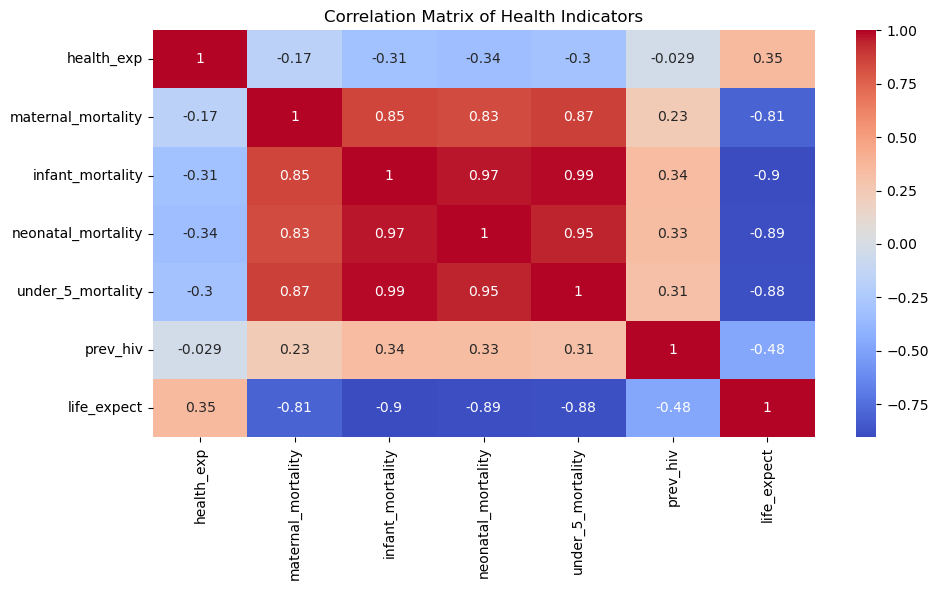

                            OLS Regression Results                            
Dep. Variable:            life_expect   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     176.9
Date:                Sun, 08 Jun 2025   Prob (F-statistic):           1.14e-65
Time:                        21:04:27   Log-Likelihood:                -379.87
No. Observations:                 158   AIC:                             773.7
Df Residuals:                     151   BIC:                             795.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             77.0201      0

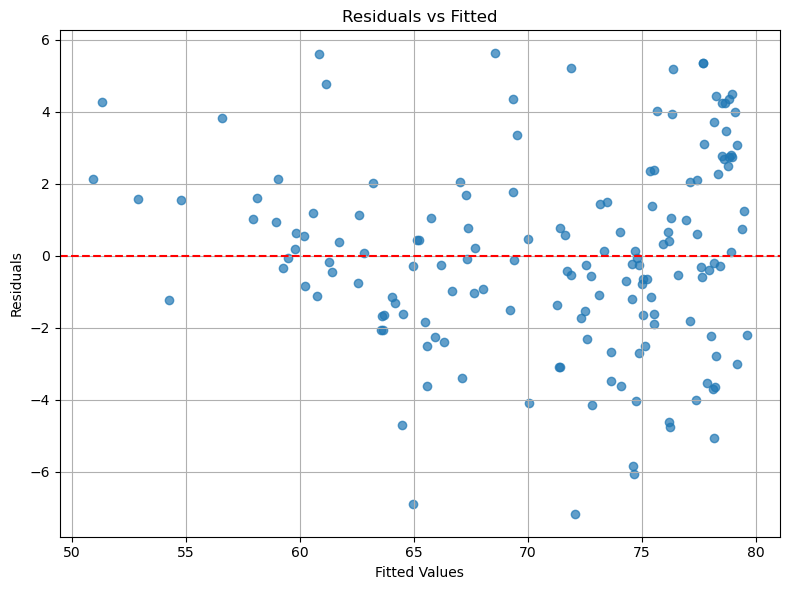

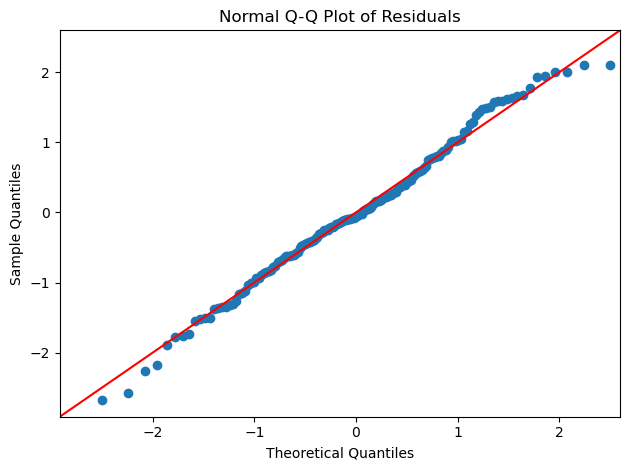

In [2]:
# ---------------------------------------------
# 04_regression_life_expectancy.ipynb
# ---------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---------------------------------------------
# Step 1: Load data (preprocessed with region & income info)
# ---------------------------------------------

df = pd.read_csv("cleaned_world_health_data.csv")

# Load World Bank mappings
mapping_df = pd.read_excel("CLASS.xlsx")
mapping_df.rename(columns={"Economy": "country"}, inplace=True)
df = df.merge(mapping_df[["country", "Region", "Income group"]], on="country", how="left")

# Filter to actual countries and latest year
df_country = df[df["entity_type"] == "country"].copy()
df_latest = df_country.sort_values("year").groupby("country").tail(1)

# ---------------------------------------------
# Step 2: Prepare features
# ---------------------------------------------

features = [
    "health_exp", "maternal_mortality", "infant_mortality",
    "neonatal_mortality", "under_5_mortality", "prev_hiv"
]

target = "life_expect"

# Drop rows with missing values in selected columns
df_reg = df_latest.dropna(subset=features + [target]).copy()

# ---------------------------------------------
# Step 3: Explore correlations
# ---------------------------------------------

plt.figure(figsize=(10, 6))
sns.heatmap(df_reg[features + [target]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Health Indicators")
plt.tight_layout()
plt.show()

# ---------------------------------------------
# Step 4: Fit multiple linear regression model
# ---------------------------------------------

formula = "life_expect ~ health_exp + maternal_mortality + infant_mortality + neonatal_mortality + under_5_mortality + prev_hiv"
model = smf.ols(formula=formula, data=df_reg).fit()

print(model.summary())

# ---------------------------------------------
# Step 5: Residual analysis
# ---------------------------------------------

# Residuals vs Fitted plot
plt.figure(figsize=(8, 6))
plt.scatter(model.fittedvalues, model.resid, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.grid(True)
plt.tight_layout()
plt.show()

# Q-Q plot
sm.qqplot(model.resid, line="45", fit=True)
plt.title("Normal Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

# ---------------------------------------------
# Step 6: Interpretation guide
# ---------------------------------------------
# - Check R-squared for model explanatory power
# - Check p-values for significance of predictors
# - Coefficients show direction/strength of each predictor
# - Ensure residuals are roughly normal + no heteroscedasticity

# Model can help identify which indicators most influence life expectancy
# Useful for targeting policy interventions and resource allocation
